In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report,f1_score

In [2]:
df = pd.read_csv("loan_approval_dataset.csv").drop_duplicates(keep = "last")

In [3]:
df.head(4)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected


In [4]:
print(df.describe())
print("-"*145)
print(df.isna().sum())
print("-"*140)
print(df.duplicated().sum())
print("-"*140)
print(df.info())

           loan_id   no_of_dependents   income_annum   loan_amount  \
count  4269.000000        4269.000000   4.269000e+03  4.269000e+03   
mean   2135.000000           2.498712   5.059124e+06  1.513345e+07   
std    1232.498479           1.695910   2.806840e+06  9.043363e+06   
min       1.000000           0.000000   2.000000e+05  3.000000e+05   
25%    1068.000000           1.000000   2.700000e+06  7.700000e+06   
50%    2135.000000           3.000000   5.100000e+06  1.450000e+07   
75%    3202.000000           4.000000   7.500000e+06  2.150000e+07   
max    4269.000000           5.000000   9.900000e+06  3.950000e+07   

         loan_term   cibil_score   residential_assets_value  \
count  4269.000000   4269.000000               4.269000e+03   
mean     10.900445    599.936051               7.472617e+06   
std       5.709187    172.430401               6.503637e+06   
min       2.000000    300.000000              -1.000000e+05   
25%       6.000000    453.000000               2.20000

In [5]:
df = df.drop("loan_id",axis = 1)

In [6]:
df.head(1)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved


In [7]:
df.columns = df.columns.str.strip()

In [8]:
df['loan_status'].value_counts(normalize = True)*100

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64

In [9]:
df['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [10]:
df = df.apply(lambda col : col.str.strip() if col.dtype == "object" else col)

In [11]:
import warnings
warnings.filterwarnings('ignore')
df['education'] = df['education'].replace({
    "Graduate":1,
    "Not Graduate" :0
})


df['self_employed'] = df['self_employed'].replace({
    "No":0,
    "Yes":1
})

df['loan_status'] = df['loan_status'].replace({
    "Approved":1,
    "Rejected":0
})

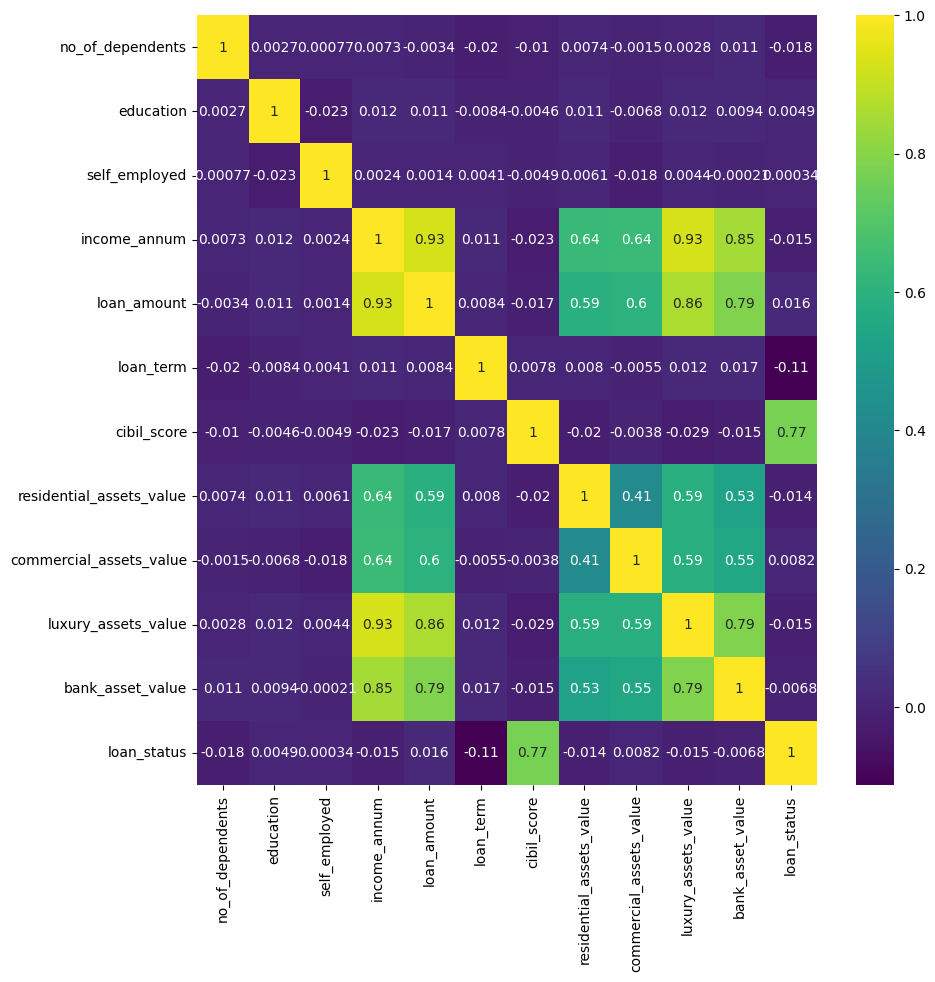

In [12]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot = True, cmap= 'viridis')
plt.show()

In [13]:
df.head(1)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1


In [14]:
X = df.drop('loan_status',axis = 1)
y = df['loan_status']

model = LogisticRegression()
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [15]:
print(confusion_matrix(y_test,y_pred))

[[275  43]
 [ 38 498]]


In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       318
           1       0.92      0.93      0.92       536

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



In [17]:
print(f1_score(y_test,y_pred))

0.924791086350975


In [18]:
model.score(X_train,y_train)

0.9203513909224011

In [19]:
model.score(X_test,y_test)

0.905152224824356

## check 

In [20]:
df.groupby('loan_status')['cibil_score'].mean()

loan_status
0    429.468072
1    703.461973
Name: cibil_score, dtype: float64

In [21]:
df.groupby('loan_status')['cibil_score'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,1613.0,429.468072,78.401752,300.0,364.0,429.0,493.0,885.0
1,2656.0,703.461973,125.249016,300.0,618.0,711.0,803.0,900.0


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced').fit(X_train,y_train)

rf_pred = rf.predict(X_test)
print(confusion_matrix(y_test,rf_pred))
print(classification_report(y_test,rf_pred))

[[306  12]
 [  4 532]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       318
           1       0.98      0.99      0.99       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [23]:
print(rf.score(X_test,y_test))
print(rf.score(X_train,y_train))

0.9812646370023419
1.0


In [24]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(
    rf,
    X,
    y,
    cv = 5
)

print(score)
print(score.mean())

[0.98009368 0.97892272 0.98477752 0.98009368 0.98358734]
0.9814949853252468


In [25]:
importance = pd.DataFrame({
    "Features":X.columns,
    "Importance":rf.feature_importances_
}).sort_values(by = 'Importance',ascending = False)

importance

,Features,Importance
6,cibil_score,0.825925
5,loan_term,0.050132
4,loan_amount,0.029458
7,residential_assets_value,0.018056
9,luxury_assets_value,0.017800
3,income_annum,0.016358
8,commercial_assets_value,0.015344
10,bank_asset_value,0.014452
0,no_of_dependents,0.007865
2,self_employed,0.002479


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier().fit(X_train,y_train)

rf_pred = rf.predict(X_test)
print(confusion_matrix(y_test,rf_pred))
print(classification_report(y_test,rf_pred))

[[305  13]
 [  6 530]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       318
           1       0.98      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



In [27]:
import joblib
joblib.dump(rf,"model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [30]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')